<a href="https://colab.research.google.com/github/RajBhatta67/measles-rubella-project/blob/main/Measles_and_Rubles_Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Checkpoint #1


In [69]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets from GitHub raw URLs
yearly_df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/measles_rubella/measles_rubella_yearly.csv')
monthly_df = pd.read_csv('https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/measles_rubella/measles_rubella_monthly.csv')


In [70]:
# Rename verbose columns to something workable
yearly_df= yearly_df.rename(columns = {'measles_incidence_rate_per_1000000_total_population': 'measles_incidence_rate',
    'rubella_incidence_rate_per_1000000_total_population': 'rubella_incidence_rate',
    'annualized_population_most_recent_year_only': 'annualized_population',
    'discarded_non_measles_rubella_cases_per_100000_total_population': 'discarded_rate',
    'total_suspected_measles_rubella_cases': 'total_suspected',
    'discarded_cases': 'discarded_total', })

In [71]:
yearly_number_columns = [
    'total_population',
    'annualized_population',
    'total_suspected',
    'measles_total',
    'measles_lab_confirmed',
    'measles_epi_linked',
    'measles_clinical',
    'measles_incidence_rate',
    'rubella_total',
    'rubella_lab_confirmed',
    'rubella_epi_linked',
    'rubella_clinical',
    'rubella_incidence_rate',
    'discarded_total',
    'discarded_rate',
]

# go through each one and force it to be a number
# if a value can't be converted it becomes NaN (blank)
for col in yearly_number_columns:
    if col in yearly_df.columns:
        yearly_df[col] = pd.to_numeric(yearly_df[col], errors='coerce')
# same thing for the monthly file
monthly_number_columns = [
    'measles_suspect',
    'measles_clinical',
    'measles_epi_linked',
    'measles_lab_confirmed',
    'measles_total',
    'rubella_clinical',
    'rubella_epi_linked',
    'rubella_lab_confirmed',
    'rubella_total',
    'discarded',
]

for col in monthly_number_columns:
    if col in monthly_df.columns:
        monthly_df[col] = pd.to_numeric(monthly_df[col], errors='coerce')

In [72]:
# year and month must be whole numbers
yearly_df['year']  = yearly_df['year'].astype(int)
monthly_df['year'] = monthly_df['year'].astype(int)
monthly_df['month'] = monthly_df['month'].astype(int)

In [73]:
# Check for missing values
yearly_df.isna().sum()

,0
region,0
country,0
iso3,0
year,0
total_population,0
annualized_population,0
total_suspected,87
measles_total,0
measles_lab_confirmed,0
measles_epi_linked,0


In [74]:
#Amount of data missing
missing_pct = yearly_df.isna().mean() * 100
print(missing_pct.round(1))

region                     0.0
country                    0.0
iso3                       0.0
year                       0.0
total_population           0.0
annualized_population      0.0
total_suspected            3.7
measles_total              0.0
measles_lab_confirmed      0.0
measles_epi_linked         0.0
measles_clinical           0.0
measles_incidence_rate     0.0
rubella_total              0.0
rubella_lab_confirmed      0.0
rubella_epi_linked         0.0
rubella_clinical           0.0
rubella_incidence_rate     0.0
discarded_total            3.7
discarded_rate            17.1
dtype: float64


In [75]:
print("\nrows before removing 2025:", len(yearly_df))
yearly_df  = yearly_df[yearly_df['year'] < 2025].copy()
monthly_df = monthly_df[monthly_df['year'] < 2025].copy()
print("rows after removing 2025 :", len(yearly_df))


rows before removing 2025: 2380
rows after removing 2025 : 2212


In [76]:
duplicates = yearly_df.duplicated(subset=['country', 'year'])
print("\nduplicate country-year rows:", duplicates.sum())



duplicate country-year rows: 0


In [77]:
# strip any extra whitespace from region names
# so 'AFRO ' and 'AFRO' don't get counted as different groups
yearly_df['region'] = yearly_df['region'].str.strip()

In [78]:
print(yearly_df['region'].value_counts())

region
EURO     632
AFRO     560
WPRO     319
AMRO     299
EMRO     264
SEARO    138
Name: count, dtype: int64


In [79]:
def get_period(year):
  if 2012 <= year <= 2019:
    return 'Pre-COVID (2012-2019)'
  elif year in [2020, 2021]:
    return 'COVID (2020-2021)'
  else:
    return 'Post-COVID (2022-2024)'

yearly_df['period'] = yearly_df['year'].apply(get_period)

In [80]:

# I will use this to color-code charts by time period

yearly_df['in_core_window']     = (yearly_df['year'] >= 2012) & (yearly_df['year'] <= 2019)
yearly_df['is_covid_disrupted'] = yearly_df['year'].isin([2020, 2021])
yearly_df['in_surge_window']    = (yearly_df['year'] >= 2022) & (yearly_df['year'] <= 2024)

In [81]:
MIN_CASES = 20

yearly_df['measles_lab_share']      = yearly_df['measles_lab_confirmed'] / yearly_df['measles_total'].replace(0, np.nan)

yearly_df['measles_clinical_share'] = yearly_df['measles_clinical']      / yearly_df['measles_total'].replace(0, np.nan)

yearly_df['rubella_lab_share']      = yearly_df['rubella_lab_confirmed'] / yearly_df['rubella_total'].replace(0, np.nan)

yearly_df['rubella_clinical_share'] = yearly_df['rubella_clinical']      / yearly_df['rubella_total'].replace(0, np.nan)

bad_measles = yearly_df['measles_lab_share'] > 1
bad_rubella = yearly_df['rubella_lab_share'] > 1
print("\nimpossible measles lab_share values (> 1):", bad_measles.sum())
print("impossible rubella lab_share values (> 1):", bad_rubella.sum())

# remove impossible values

yearly_df.loc[bad_measles, 'measles_lab_share'] = np.nan
yearly_df.loc[bad_rubella, 'rubella_lab_share'] = np.nan

# flag rows where we have enough cases to trust the ratio
yearly_df['measles_denom_ok'] = yearly_df['measles_total'] >= MIN_CASES
yearly_df['rubella_denom_ok']  = yearly_df['rubella_total']  >= MIN_CASES

# log incidence for plotting (fixes skew from large outbreaks)
yearly_df['measles_log_incidence'] = np.log1p(yearly_df['measles_incidence_rate'])
yearly_df['rubella_log_incidence']  = np.log1p(yearly_df['rubella_incidence_rate'])

print("\nmeasles lab_share (core window, >= 20 cases):")
core_m = yearly_df[yearly_df['in_core_window'] & yearly_df['measles_denom_ok']]
print(core_m['measles_lab_share'].describe().round(3))

print("\nrubella lab_share (core window, >= 20 cases):")
core_r = yearly_df[yearly_df['in_core_window'] & yearly_df['rubella_denom_ok']]
print(core_r['rubella_lab_share'].describe().round(3))


impossible measles lab_share values (> 1): 0
impossible rubella lab_share values (> 1): 0

measles lab_share (core window, >= 20 cases):
count    727.000
mean       0.609
std        0.340
min        0.000
25%        0.294
50%        0.688
75%        0.938
max        1.000
Name: measles_lab_share, dtype: float64

rubella lab_share (core window, >= 20 cases):
count    353.000
mean       0.860
std        0.300
min        0.000
25%        0.944
50%        1.000
75%        1.000
max        1.000
Name: rubella_lab_share, dtype: float64


In [83]:
yearly_df = yearly_df.sort_values(['country', 'year']).reset_index(drop=True)

# each country's own typical measles incidence
yearly_df['country_median_incidence'] = (
    yearly_df
    .groupby('country')['measles_incidence_rate']
    .transform('median')
)

# outbreak = more than 2x their own normal AND at least 20 cases
yearly_df['measles_outbreak_year'] = (
    (yearly_df['measles_incidence_rate'] > 2.0 * yearly_df['country_median_incidence']) &
    (yearly_df['measles_total'] >= MIN_CASES)
)

print("\noutbreak years flagged:", yearly_df['measles_outbreak_year'].sum())


outbreak years flagged: 466


In [86]:
# Build the measles rows
measles_rows = yearly_df[[
    'country', 'iso3', 'region', 'year', 'period',
    'total_population', 'in_core_window',
    'in_surge_window', 'is_covid_disrupted'
]].copy()
measles_rows['disease']        = 'measles'
measles_rows['total_cases']    = yearly_df['measles_total'].values
measles_rows['lab_confirmed']  = yearly_df['measles_lab_confirmed'].values
measles_rows['epi_linked']     = yearly_df['measles_epi_linked'].values
measles_rows['clinical']       = yearly_df['measles_clinical'].values
measles_rows['incidence_rate'] = yearly_df['measles_incidence_rate'].values
measles_rows['log_incidence']  = yearly_df['measles_log_incidence'].values
measles_rows['lab_share']      = yearly_df['measles_lab_share'].values
measles_rows['clinical_share'] = yearly_df['measles_clinical_share'].values
measles_rows['denom_ok']       = yearly_df['measles_denom_ok'].values
measles_rows['outbreak_year']  = yearly_df['measles_outbreak_year'].values

# rubella rows
rubella_rows = yearly_df[[
    'country', 'iso3', 'region', 'year', 'period',
    'total_population', 'in_core_window',
    'in_surge_window', 'is_covid_disrupted'
]].copy()
rubella_rows['disease']        = 'rubella'
rubella_rows['total_cases']    = yearly_df['rubella_total'].values
rubella_rows['lab_confirmed']  = yearly_df['rubella_lab_confirmed'].values
rubella_rows['epi_linked']     = yearly_df['rubella_epi_linked'].values
rubella_rows['clinical']       = yearly_df['rubella_clinical'].values
rubella_rows['incidence_rate'] = yearly_df['rubella_incidence_rate'].values
rubella_rows['log_incidence']  = yearly_df['rubella_log_incidence'].values
rubella_rows['lab_share']      = yearly_df['rubella_lab_share'].values
rubella_rows['clinical_share'] = yearly_df['rubella_clinical_share'].values
rubella_rows['denom_ok']       = yearly_df['rubella_denom_ok'].values
rubella_rows['outbreak_year']  = np.nan

tidy_df = pd.concat([measles_rows, rubella_rows], ignore_index=True)
tidy_df = tidy_df.sort_values(['country', 'year', 'disease']).reset_index(drop=True)

print("\ntidy_df shape:", tidy_df.shape)
tidy_df[['country', 'year', 'disease', 'total_cases', 'lab_share', 'period']].head(6)



tidy_df shape: (4424, 20)


,country,year,disease,total_cases,lab_share,period
0,Afghanistan,2012,measles,2791,0.949122,Pre-COVID (2012-2019)
1,Afghanistan,2012,rubella,88,0.988636,Pre-COVID (2012-2019)
2,Afghanistan,2013,measles,430,0.960465,Pre-COVID (2012-2019)
3,Afghanistan,2013,rubella,20,1.000000,Pre-COVID (2012-2019)
4,Afghanistan,2014,measles,552,0.891304,Pre-COVID (2012-2019)
5,Afghanistan,2014,rubella,46,1.000000,Pre-COVID (2012-2019)


In [85]:
# how many months out of 12 does each country actually report? # rubella monthly data turns out to be very sparse # this is why we will do the main analysis on yearly data
monthly_df['measles_reported'] = monthly_df['measles_total'].notna()
monthly_df['rubella_reported']  = monthly_df['rubella_total'].notna()

completeness = monthly_df.groupby(['country', 'year']).agg(
    measles_months_reported = ('measles_reported', 'sum'),
    rubella_months_reported = ('rubella_reported', 'sum'),
).reset_index()

completeness['measles_completeness'] = completeness['measles_months_reported'] / 12
completeness['rubella_completeness']  = completeness['rubella_months_reported'] / 12

The research question im leaning towards:
To what extent is the reported divergence between measles and rubella incidence across 193 countries (2012–2024) attributable to rubella incidence being more dependent on a country’s lab-confirmation share than measles incidence is?


Checkpoint #2


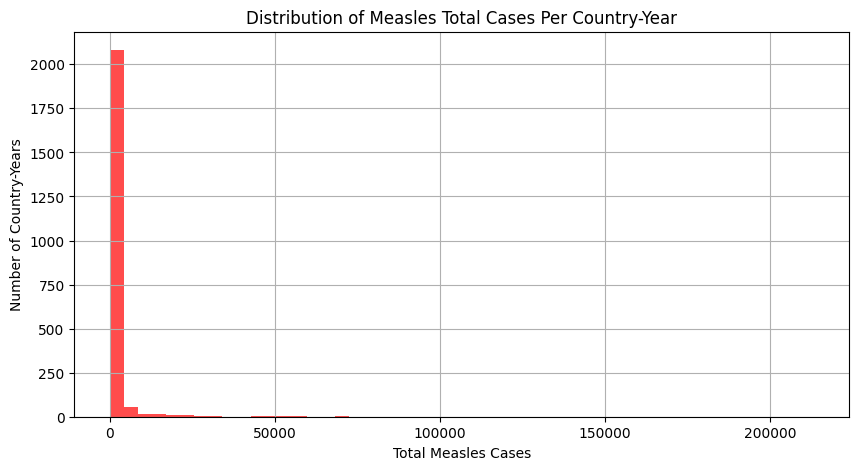

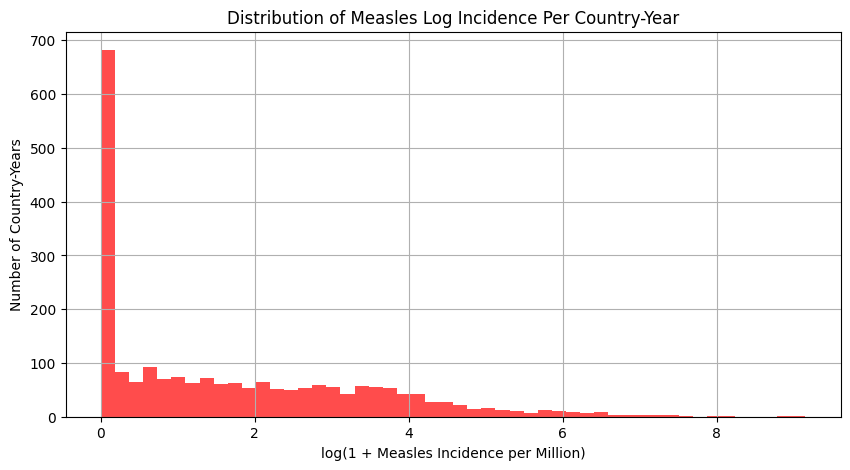

In [87]:
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['measles_total'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('Distribution of Measles Total Cases Per Country-Year')
plt.xlabel('Total Measles Cases')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()

# --- 1c. same thing but log scale so we can actually see the shape ---
plt.figure(figsize=(10, 5))
plt.hist(yearly_df['measles_log_incidence'].dropna(), bins=50, color='red', alpha=0.7)
plt.title('Distribution of Measles Log Incidence Per Country-Year')
plt.xlabel('log(1 + Measles Incidence per Million)')
plt.ylabel('Number of Country-Years')
plt.grid()
plt.show()


--- WHO regions ---
region
EURO     632
AFRO     560
WPRO     319
AMRO     299
EMRO     264
SEARO    138
Name: count, dtype: int64

--- time periods ---
period
Pre-COVID (2012-2019)     1356
Post-COVID (2022-2024)     528
COVID (2020-2021)          328
Name: count, dtype: int64

--- diseases in tidy_df ---
disease
measles    2212
rubella    2212
Name: count, dtype: int64


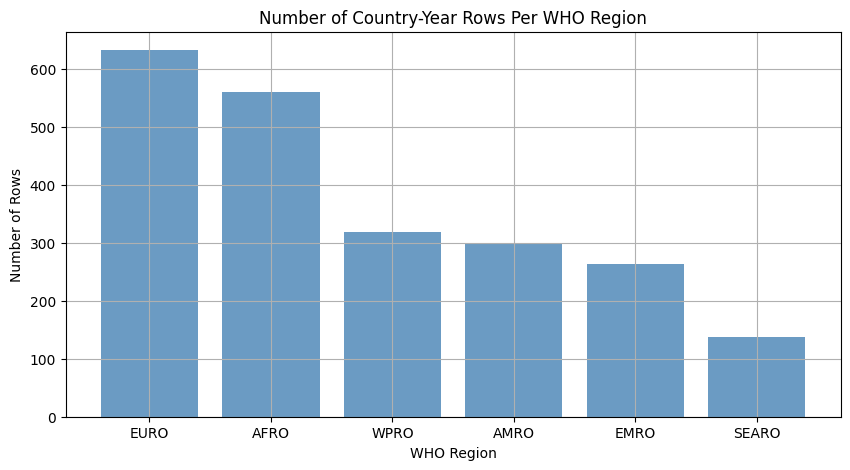

In [88]:
print("\n--- WHO regions ---")
print(yearly_df['region'].value_counts())

print("\n--- time periods ---")
print(yearly_df['period'].value_counts())

print("\n--- diseases in tidy_df ---")
print(tidy_df['disease'].value_counts())

# bar chart of country-years per region
region_counts = yearly_df['region'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(region_counts.index, region_counts.values, color='steelblue', alpha=0.8)
plt.title('Number of Country-Year Rows Per WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Number of Rows')
plt.grid()
plt.show()